## 概要

実習3_6です。与えられたデータを基に学習を深めてみましょう。

前回のモジュールでトレーニングしたモデルを評価します。また、テストデータの結果に基づいてメトリクスを計算します。
## 業務シナリオの紹介

あなたはある医療機関に勤務しており、乳癌（にゅうがん、英: Breast cancer）の検出を改善したいと考えています。

機械学習 (ML) を利用してこの問題を解決するのがあなたの課題です。このデータセットを使用して ML モデルのトレーニングを行い、患者に異常があるかどうかを予測します。

## このデータセットについて

breast_cancer.csv　は、Pythonのscikit-learn付属データセットに用意されており、ダウンロードしたデータです。

## 属性情報

PowerPointをご覧ください。
このデータセットの詳細については、 (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) を参照してください。

## データのインポートとモデルのトレーニング

以下の3つのセルは、前回の3-5のコードをまとめたものです。
実行するとデータがインポートされ、使用できる状態になります。

**注:** 次のセルは、以前のラボでの重要なステップです。消さないように注意
**fit** を実行するとモデルがトレーニングされます。
**注:** この処理は最長15分かかることがあります。


In [1]:
# S3のバケット名を指定するための変数を作成（ご自身のパケットに変更）
bucket='machinelearning0105'

In [2]:
# 警告メッセージを無視するためにwarningsモジュールを使用
import warnings, requests, zipfile, io

# 警告メッセージを無視するフィルターを設定
warnings.simplefilter('ignore')

# データ処理のためにpandasモジュールをインポート
import pandas as pd

# 科学技術計算のためにscipyモジュールからarffファイルの入出力関数をインポート
from scipy.io import arff

# ローカルのオペレーティングシステムにアクセスするためにosモジュールをインポート
import os

# AWSのSageMakerサービスを使用するためにboto3とsagemakerモジュールをインポート
import boto3
import sagemaker

# SageMakerにおけるデフォルトのコンテナイメージを取得するためにretrieveメソッドを使用
from sagemaker.image_uris import retrieve

# データをトレーニングセットとテストセットに分割するためにtrain_test_splitメソッドを使用
from sklearn.model_selection import train_test_split

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [3]:
# pandasライブラリを使って、AWS S3上のCSVファイルを読み込む
# 事前に必要なデータをS3にアップロードをして、URIをメモしておいてください。
df = pd.read_csv('s3://machinelearning0105/breast_cancer.csv')

# DataFrameの列名をリストに変換
cols = df.columns.tolist()

# 先頭の列を末尾に移動するためにスライスを使用
cols = cols[-1:] + cols[:-1]

# 列の順序を変更するためにDataFrameを再構築
df = df[cols]

# データセットをトレーニングセットとテスト＆検証セットに分割するためにtrain_test_split関数を使用
# test_sizeでテスト＆検証セットの割合を指定し、random_stateで乱数のシードを固定
# stratifyでクラスの分布を保持して分割
train, test_and_validate = train_test_split(df, test_size=0.2, random_state=42, stratify=df['target'])

# train_test_split関数を使用してデータを分割
# test_and_validateデータをtestとvalidateに分割し、test_sizeで分割比率を指定
# random_stateで再現性を確保し、stratifyで層別サンプリングを行う（'class'列を考慮）
test, validate = train_test_split(test_and_validate, test_size=0.5, random_state=42, stratify=test_and_validate['target'])

# S3バケットとプレフィックスの設定
prefix='lab3'

# 訓練データ、テストデータ、検証データのファイル名設定
train_file='vertebral_train.csv'
test_file='vertebral_test.csv'
validate_file='vertebral_validate.csv'

# S3リソースを取得
s3_resource = boto3.Session().resource('s3')

# S3にCSVファイルをアップロードするための関数を定義
def upload_s3_csv(filename, folder, dataframe):
    csv_buffer = io.StringIO()
    dataframe.to_csv(csv_buffer, header=False, index=False)
    s3_resource.Bucket(bucket).Object(os.path.join(prefix, folder, filename)).put(Body=csv_buffer.getvalue())
    
# train_fileというCSVファイルをS3にアップロードするためにupload_s3_csv関数を使用
upload_s3_csv(train_file, 'train', train)

# test_fileというCSVファイルをS3にアップロードするためにupload_s3_csv関数を使用
upload_s3_csv(test_file, 'test', test)

# validate_fileというCSVファイルをS3にアップロードするためにupload_s3_csv関数を使用
upload_s3_csv(validate_file, 'validate', validate)

# SageMakerにおいてXGBoostアルゴリズムを利用するためのコンテナイメージを取得
container = retrieve('xgboost',boto3.Session().region_name,'1.0-1')

# XGBoostのハイパーパラメータを設定するための辞書を作成
hyperparams={"num_round":"42",
             "eval_metric": "auc",
             "objective": "binary:logistic"}

# 出力先のS3ロケーションを設定
s3_output_location="s3://{}/{}/output/".format(bucket,prefix)

# SageMakerのXGBoostアルゴリズムを使用するためにXGBoost Estimatorを作成
# container: 使用するコンテナの指定
# sagemaker.get_execution_role(): SageMakerの実行ロールを取得
# instance_count: モデルトレーニングに使用するインスタンスの数を指定
# instance_type: モデルトレーニングに使用するインスタンスのタイプを指定
# output_path: トレーニングアーティファクト（モデルアーティファクト）のS3出力先を指定
# hyperparameters: XGBoostのハイパーパラメータを指定
# sagemaker_session: SageMakerセッションを指定
xgb_model=sagemaker.estimator.Estimator(container,
                                       sagemaker.get_execution_role(),
                                       instance_count=1,
                                       instance_type='ml.m4.xlarge',
                                       output_path=s3_output_location,
                                        hyperparameters=hyperparams,
                                        sagemaker_session=sagemaker.Session())

# SageMakerのトレーニングジョブに使用するトレーニングデータのS3パスとコンテントタイプを指定
train_channel = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/train/".format(bucket,prefix,train_file),
    content_type='text/csv')

# SageMakerのトレーニングジョブに使用する検証データのS3パスとコンテントタイプを指定
validate_channel = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/validate/".format(bucket,prefix,validate_file),
    content_type='text/csv')

# トレーニングジョブのデータチャネルにトレーニングデータと検証データを指定
data_channels = {'train': train_channel, 'validation': validate_channel}

# XGBoostモデルを学習させるためにfitメソッドを使用
# inputsにはデータチャネルを指定し、logsをFalseに設定してログを表示しないようにする
xgb_model.fit(inputs=data_channels, logs=False)

# ホスティングの準備が完了したことを表示
print('ready for hosting!')

# テストデータから特徴量を抽出し、1列目以降を取得
batch_X = test.iloc[:,1:];

# バッチデータの入力ファイル名を指定
batch_X_file='batch-in.csv'

# バッチデータをS3にアップロード
upload_s3_csv(batch_X_file, 'batch-in', batch_X)

# バッチ変換の出力先を指定
batch_output = "s3://{}/{}/batch-out/".format(bucket,prefix)

# バッチ変換の入力データのパスを指定
batch_input = "s3://{}/{}/batch-in/{}".format(bucket,prefix,batch_X_file)

# XGBoostトランスフォーマーを作成
# instance_count: トランスフォーマーの実行に使用するインスタンスの数
# instance_type: トランスフォーマーのインスタンスのタイプ
# strategy: バッチ変換のストラテジーを指定（MultiRecordは複数の入力レコードに対応）
# assemble_with: バッチ変換の際に結果をどのようにまとめるか指定（Lineは行ごとにまとめる）
# output_path: バッチ変換の結果を保存するS3のパスを指定
xgb_transformer = xgb_model.transformer(instance_count=1,
                                       instance_type='ml.m4.xlarge',
                                       strategy='MultiRecord',
                                       assemble_with='Line',
                                       output_path=batch_output)

# バッチ変換を実行
# data: 変換対象のデータのパスを指定
# data_type: 変換対象のデータのタイプを指定（S3PrefixはS3上のプレフィックス内のデータを指定）
# content_type: 変換対象データのコンテンツタイプを指定
# split_type: 入力データをどのように分割するか指定（Lineは行ごとに分割）
xgb_transformer.transform(data=batch_input,
                         data_type='S3Prefix',
                         content_type='text/csv',
                         split_type='Line')

# バッチ変換が完了するのを待機
xgb_transformer.wait()

# バッチ変換完了が完了したことを表示
print('Batch transformation completed!')

# boto3モジュールを使用してS3クライアントを作成
s3 = boto3.client('s3')

# S3バケットからオブジェクトを取得
obj = s3.get_object(Bucket=bucket, Key="{}/batch-out/{}".format(prefix,'batch-in.csv.out'))

# バッチ変換の結果として得られた予測結果を読み込む
# ここではCSVデータを読み込み、列名を指定してDataFrameに変換
target_predicted = pd.read_csv(io.BytesIO(obj['Body'].read()),sep=',',names=['target'])

# 全て完了が完了したことを表示
print('ALL completed!')

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2024-01-07-03-09-58-926



2024-01-07 03:09:59 Starting - Starting the training job........
2024-01-07 03:10:47 Starting - Preparing the instances for training............
2024-01-07 03:11:52 Downloading - Downloading input data.....
2024-01-07 03:12:22 Downloading - Downloading the training image.........
2024-01-07 03:13:12 Training - Training image download completed. Training in progress....
2024-01-07 03:13:36 Uploading - Uploading generated training model..
2024-01-07 03:13:47 Completed - Training job completed
ready for hosting!


INFO:sagemaker:Creating model with name: sagemaker-xgboost-2024-01-07-03-13-51-499
INFO:sagemaker:Creating transform job with name: sagemaker-xgboost-2024-01-07-03-13-52-185


...................................[2024-01-07:03:19:43:INFO] No GPUs detected (normal if no gpus installed)
[2024-01-07:03:19:43:INFO] No GPUs detected (normal if no gpus installed)
[2024-01-07:03:19:43:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|invocations|execution-parameters) {
      proxy_set_header X-Forwarded-For $proxy_add_x_forwarded_for;
      proxy_set_header Host $http_host;
      proxy_redirect off;
      proxy_read_timeout 60s;
      proxy_pass http://gunicorn;
    }
    location / {
      return 404 "{}";
    }
  }
}
[2024-01-07 03:19:44 +0000] [19] [INFO] Starting 

# ステップ 1: 結果の調査

モデルからの出力は確率になります。まずはその確率を、*0* または *1* の 2 つのクラスのいずれかに変換する必要があります。その準備として、変換を実行するための関数を作成します。関数内でのしきい値の使い方に留意してください。

In [4]:
# 閾値を設定して二値変換する関数を定義
# binary_convert関数では、確率が指定された閾値（ここでは0.65）より大きい場合は1、それ以外は0に変換されます。
def binary_convert(x):
    threshold = 0.65
    if x > threshold:
        return 1
    else:
        return 0

# 'class'列の各要素に二値変換を適用し、新しい 'binary' 列を作成
target_predicted_binary = target_predicted['target'].apply(binary_convert)

# 最初の10行を表示して、変換が正しく適用されていることを確認
print(target_predicted_binary.head(10))

# テストデータの最初の10行を表示
test.head(10)

0    1
1    1
2    1
3    1
4    0
5    1
6    1
7    1
8    0
9    1
Name: target, dtype: int64


,target,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
415,1,11.89,21.17,76.39,433.8,0.09773,0.08120,0.02555,0.02179,0.2019,...,13.050,27.21,85.09,522.9,0.14260,0.21870,0.11640,0.08263,0.3075,0.07351
235,1,14.03,21.25,89.79,603.4,0.09070,0.06945,0.01462,0.01896,0.1517,...,15.330,30.28,98.27,715.5,0.12870,0.15130,0.06231,0.07963,0.2226,0.07617
568,1,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.00000,0.00000,0.2871,0.07039
488,1,11.68,16.17,75.49,420.5,0.11280,0.09263,0.04279,0.03132,0.1853,...,13.320,21.59,86.57,549.8,0.15260,0.14770,0.14900,0.09815,0.2804,0.08024
14,0,13.73,22.61,93.60,578.3,0.11310,0.22930,0.21280,0.08025,0.2069,...,15.030,32.01,108.80,697.7,0.16510,0.77250,0.69430,0.22080,0.3596,0.14310
375,1,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,...,16.970,19.14,113.10,861.5,0.12350,0.25500,0.21140,0.12510,0.3153,0.08960
41,0,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,...,12.840,35.34,87.22,514.0,0.19090,0.26980,0.40230,0.14240,0.2964,0.09606
288,1,11.26,19.96,73.72,394.1,0.08020,0.11810,0.09274,0.05588,0.2595,...,11.860,22.33,78.27,437.6,0.10280,0.18430,0.15460,0.09314,0.2955,0.07009
198,0,19.18,22.49,127.50,1148.0,0.08523,0.14280,0.11140,0.06772,0.1767,...,23.360,32.06,166.40,1688.0,0.13220,0.56010,0.38650,0.17080,0.3193,0.09221
296,1,10.91,12.35,69.14,363.7,0.08518,0.04721,0.01236,0.01369,0.1449,...,11.370,14.82,72.42,392.2,0.09312,0.07506,0.02884,0.03194,0.2143,0.06643


これらの結果から、最初のモデルはそれほど精度が良いと言えないことがわかります。少数の値を比較することで判断するのは困難です。

次では、メトリクスをいくつか作成してモデルのパフォーマンスを確認します。


# ステップ 2: 混同行列の作成

*混同行列* は、分類モデルのパフォーマンスを測定する主要な方法の 1 つです。これは正しい予測と誤った予測を描き出したテーブルです。モデルの混同行列計算後に、他の統計も作成できます。ただし、混同行列の作成から始めてください。

混同行列を作成するには、テストデータのターゲット値 *と* 予測値の両方が必要です。

テスト用の DataFrame からターゲットを取得します。

In [5]:
# テストデータのクラスラベル列を抽出する
test_labels = test.iloc[:,0]

# headメソッドを使用して、抽出したクラスラベル列の最初の数行を表示する
test_labels.head()

415    1
235    1
568    1
488    1
14     0
Name: target, dtype: int64

これで、混同行列を作成する関数を含む *scikit-learn* ライブラリを使用できます。

In [6]:
# scikit-learnから混同行列を計算するためのメトリクスをインポート
from sklearn.metrics import confusion_matrix

# テストデータの真のクラスラベル（test_labels）と予測されたクラスラベル（target_predicted_binary）に基づいて混同行列を計算
matrix = confusion_matrix(test_labels, target_predicted_binary)

# 混同行列をDataFrameに変換し、見やすくするために行と列にラベルを付ける
df_confusion = pd.DataFrame(matrix, index=['Nnormal','Abnormal'],columns=['Normal','Abnormal'])

# 混同行列の表示
df_confusion

,Normal,Abnormal
Nnormal,20,1
Abnormal,0,36


多少の違いはあっても、この例と同じような結果が得られるはずです。

_ | Normal | Abnormal
---------- | ----: | ----:
Normal | 20  | 1
Abnormal | 0  | 36



上にある例の表では、モデルが *Normal 20 件* と *Abnormal 36 件* の値を正しく予測したことを示しています。しかし、*Normal 1 件* を誤って予測しています。

*seaborn* と *matplotlib* という Python ライブラリを使用すると、これらの値を図表化して読みやすくすることができます。

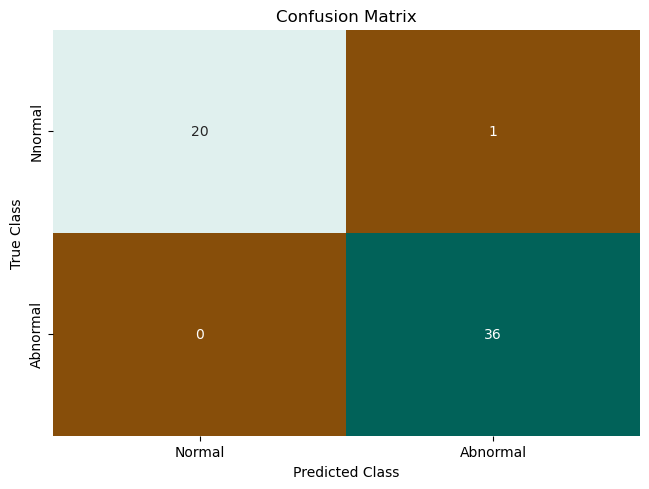

In [7]:
# データの可視化に使用するSeabornモジュールとMatplotlibのpyplotモジュールをインポート
import seaborn as sns
import matplotlib.pyplot as plt

# カラーマップを生成するためにSeabornで提供されている色のパレットを指定
colormap = sns.color_palette("BrBG", 10)

# 混同行列（Confusion Matrix）をヒートマップとして可視化
# annot=Trueでセルに数値を表示、cbar=Noneでカラーバーを非表示、cmapでカラーマップを指定
sns.heatmap(df_confusion, annot=True, cbar=None, cmap=colormap)

# プロットのタイトルを設定
plt.title("Confusion Matrix")

# グラフのレイアウトを整える
plt.tight_layout()

# y軸のラベルを設定
plt.ylabel("True Class")

# x軸のラベルを設定
plt.xlabel("Predicted Class")

# ヒートマップを表示
plt.show()

**ヒント:** グラフが 1 回目で表示されない場合は、再度セルを実行してみましょう。

全体的にうまく予測できていますが、問題演習のため引き続きおこなっていきます。

# ステップ 3: パフォーマンス統計の計算

このモデルを次に作成するモデルと比較する場合は、記録できるメトリクスが必要です。バイナリー分類の問題に対しては、混同行列データを使用してさまざまなメトリクスを計算できます。

まず、混同行列セルから値を抽出して変数に代入します。

In [8]:
# scikit-learnからROC曲線の評価指標や混同行列を計算するためのメソッドをインポート
from sklearn.metrics import roc_auc_score, roc_curve, auc

# 混同行列から真陰性（TN）、偽陽性（FP）、偽陰性（FN）、真陽性（TP）の各要素を計算しています。
# これにより、モデルの予測がどれだけ正確かや、偽陽性や偽陰性の数がどれくらいかなどを評価できます。
TN, FP, FN, TP = confusion_matrix(test_labels, target_predicted_binary).ravel()

# 各要素を表示して、モデルの予測性能を評価
print(f"True Negative (TN) : {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"True Positive (TP) : {TP}")

True Negative (TN) : 20
False Positive (FP): 1
False Negative (FN): 0
True Positive (TP) : 36


これでいくつかの統計値を計算できます。


### 感度

*感度* は、*ヒット率*、*検出率*、または *正検出率 (TPR)* とも言います。これは、実際の陽性例が正しく陽性と判定される割合を測定します。

この例で、感度は、*異常がある患者の異常を検出する確率* のことです。

In [9]:
# Sensitivity（感度）は、実際に陽性のサンプル（True Positive）を正しく検出する割合を示します。
# True Positive（TP）は実際に陽性で、モデルも陽性と予測したサンプル数を指します。
# False Negative（FN）は実際に陽性で、モデルが陰性と予測したサンプル数を指します。

# Sensitivityを計算し、パーセンテージで表示
Sensitivity  = float(TP)/(TP+FN)*100
print(f"Sensitivity or TPR: {Sensitivity}%")

# Sensitivityの意味を説明する文を表示
print(f"There is a {Sensitivity}% chance of detecting patients with an abnormality have an abnormality")

Sensitivity or TPR: 100.0%
There is a 100.0% chance of detecting patients with an abnormality have an abnormality


**質問:** このシナリオで感度は十分ですか?


### 特異度

続いての統計は *特異度*です。別名「*真陰性*」とも言います。これは、実際の陰性例が正しく陰性と判定される割合を測定します。

この例で、特異度は、*正常である患者群に対する正常検出の確率* のことです。

In [10]:
# 特異度（Specificity）または真陰性率（True Negative Rate）を計算する
# TN: 真陰性の数（正しく陰性と予測されたサンプルの数）
# FP: 偽陽性の数（実際は陰性だが誤って陽性と予測されたサンプルの数）
Specificity  = float(TN)/(TN+FP)*100

# 特異度または真陰性率を表示する
print(f"Specificity or TNR: {Specificity}%") 

# メッセージを表示して、正常な患者が正常と検出される確率を説明する
print(f"There is a {Specificity}% chance of detecting normal patients are normal.")


Specificity or TNR: 95.23809523809523%
There is a 95.23809523809523% chance of detecting normal patients are normal.


**質問:** この特異度は過小、適正、過大のどれに当てはまりますか? シナリオを考慮すると、ここではどのような値を期待しますか?



### 陽性予測値と陰性予測値

*適合率*、または *陽性予測値* とは、陽性判定の比率を示します。

この例で、陽性予測値は、*スクリーニング試験で陽性判定の被験者に実際に異常がある確率* のことです。

In [11]:
# 精度または陽性的中率（Precision）を計算する
# TP（True Positive）は正しく陽性と予測されたサンプル数を表す
# FP（False Positive）は実際は陰性だが誤って陽性と予測されたサンプル数を表す
Precision = float(TP)/(TP+FP)*100

# 精度を表示
print(f"Precision: {Precision}%") 

# メッセージを表示して、陽性と予測された場合の正しさの確率を示す
print(f"You have an abnormality, and the probablity that is correct is {Precision}%")

Precision: 97.2972972972973%
You have an abnormality, and the probablity that is correct is 97.2972972972973%


*陰性予測値*は、陰性判定の比率です。

この例で、陰性予測値は、*スクリーニング試験で陰性判定の被験者に実際は異常がない確率* のことです。

In [12]:
# 負の予測値（Negative Predictive Value, NPV）を計算する
# NPVは、実際に正しく陰性と予測されたケースの割合を示す指標で、真陰性（TN）を陰性と予測された総数で割って算出
NPV = float(TN)/(TN+FN)*100

# NPVを表示
print(f"Negative Predictive Value: {NPV}%")

# ユーザーに向けてメッセージを表示
print(f"You don't have an abnormality, but there is a {NPV}% chance that is incorrect" )

Negative Predictive Value: 100.0%
You don't have an abnormality, but there is a 100.0% chance that is incorrect


これらの値が及ぼす影響を考えてみましょう。異常を調べる検査で陽性と判定されたら、患者はどれほど不安な気持ちになるでしょうか? 反対に検査結果が陰性なら、どれほど安心できるでしょうか?


### 偽陽性率

*偽陽性率 (FPR)* とは、誤ったアラームが発生する確率、または *実際の値が陰性の場合に陽性と判定される* 確率のことです。

In [13]:
# フォールアウトまたは偽陽性率（False Positive Rate）を計算する
# 偽陽性（False Positive）は、実際は陰性なのに陽性と判定されるケースを指し、
# その割合を計算しています。
FPR = float(FP)/(FP+TN)*100

# 計算結果を表示
print( f"False Positive Rate: {FPR}%") 

# 結果の意味を補足して表示
print( f"There is a {FPR}% chance that this positive result is incorrect.")

False Positive Rate: 4.761904761904762%
There is a 4.761904761904762% chance that this positive result is incorrect.


### 偽陰性率

*偽陰性率*、または *未検出率* とは、*検査によって実際の陽性例が見逃される* 確率のことです。

In [14]:
# False Negative Rate（偽陰性率）を計算するための式を設定
FNR = float(FN)/(TP+FN)*100

# False Negative Rateを表示する
print(f"False Negative Rate: {FNR}%") 

# 解釈: この結果が陰性である場合、それが誤りである確率はFNR%である可能性があります。
print(f"There is a {FNR}% chance that this negative result is incorrect.")

False Negative Rate: 0.0%
There is a 0.0% chance that this negative result is incorrect.


### 誤検出率

この例で、 *誤検出率* は、*患者に異常がない場合に異常を予測する確率* のことです。

In [15]:
# False Discovery Rate（偽陽性率）を計算するための式を設定
FDR = float(FP)/(TP+FP)*100

# False Discovery Rateを表示する
print(f"False Discovery Rate: {FDR}%" )

# 解釈: この結果が陽性である場合、それが誤りである確率はFDR%である可能性があります。
print(f"You have an abnormality, but there is a {FDR}% chance this is incorrect.")

False Discovery Rate: 2.7027027027027026%
You have an abnormality, but there is a 2.7027027027027026% chance this is incorrect.


### 総合正解率

モデルの精度はどのように判断するのでしょうか?

In [16]:
# 全体の正確度（Overall accuracy）を計算するための式を設定
ACC = float(TP+TN)/(TP+FP+FN+TN)*100

# 全体の正確度を表示する
print(f"Accuracy: {ACC}%") 

Accuracy: 98.24561403508771%


要約すると、モデルから次のメトリクスを算出しました。

In [17]:
# Sensitivity（感度）または True Positive Rate（真陽性率）を表示
print(f"Sensitivity or TPR: {Sensitivity}%") 

# Specificity（特異度）または True Negative Rate（真陰性率）を表示
print(f"Specificity or TNR: {Specificity}%") 

# Precision（適合率）を表示
print(f"Precision: {Precision}%") 

# Negative Predictive Value（陰性的中率）を表示
print(f"Negative Predictive Value: {NPV}%")

# False Positive Rate（偽陽性率）を表示
print( f"False Positive Rate: {FPR}%") 

# False Negative Rate（偽陰性率）を表示
print(f"False Negative Rate: {FNR}%") 

# False Discovery Rate（偽陽性発見率）を表示
print(f"False Discovery Rate: {FDR}%" )

# Accuracy（正解率）を表示
print(f"Accuracy: {ACC}%") 

Sensitivity or TPR: 100.0%
Specificity or TNR: 95.23809523809523%
Precision: 97.2972972972973%
Negative Predictive Value: 100.0%
False Positive Rate: 4.761904761904762%
False Negative Rate: 0.0%
False Discovery Rate: 2.7027027027027026%
Accuracy: 98.24561403508771%


**チャレンジ課題:** 前の値を記録してからステップ 1 に戻り、しきい値に使用する値を変更します。試すべき値は、*.25* と*.75* です。

このしきい値によって違いが生じたでしょうか?

# ステップ 4: AUC-ROC 曲線の計算

scikit-learn ライブラリには、受信者操作特性曲線 (AUC-ROC)* 下面積* の計算に便利な関数があります。

- ROC は確率曲線です。
- AUC は、モデルがクラス間を判別する精度を示します。

AUC は計算で求めることができます。次回のラボで取り上げますが、モデルのパフォーマンスを測定する基準として使用できます。

この例では AUC が高いほど、モデルは、異常がある患者と正常な患者の判別に優れていることになります。

しきい値に設定した値に応じて、AUC は変化し得ます。変換されたクラスの代わりに確率を使用することで、AUC をプロットできます。


In [18]:
# テストデータのクラスラベル列を抽出し、変数test_labelsに格納
test_labels = test.iloc[:,0];

# roc_auc_score関数を使用して、予測されたクラスと実際のクラスラベルとの間でROC AUCを計算
# このスコアはモデルの分類性能を評価する指標で、1に近いほど良い性能を示す

#0.5: モデルがランダムな予測をしている場合。クラスの分離能力がない。
#0.7から0.8: 良好な性能。一般的には受け入れられる範囲とされます。
#0.8から0.9: 非常に良好な性能。信頼性が高く、優れた分類モデルとされます。
#0.9以上: 優れた性能。非常に高い信頼性と分類能力があるとされます。

print("Validation AUC", roc_auc_score(test_labels, target_predicted) )

Validation AUC 1.0


通常、ROC 曲線は FPR に対する TPR の形でプロットされます。その場合、TPR は Y 軸、FPR は X 軸になります。

scikit-learn には、プロットする値の生成に便利な **roc_curve** 関数があります。

Figure(640x480)


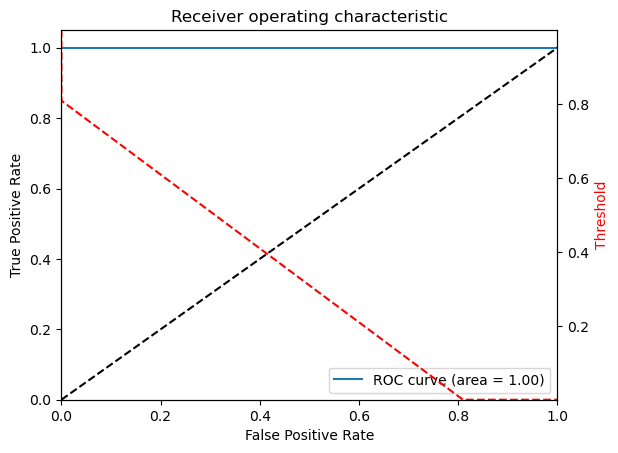

<Figure size 640x480 with 0 Axes>

In [19]:
# numpyライブラリを np としてインポート
import numpy as np

# ROC曲線を生成するためにroc_curve関数を使用
# test_labelsは実際のクラスラベル、target_predictedは予測されたクラスラベル
# roc_curve関数は、実際のクラスラベル（test_labels）と、それに対応する予測されたクラスラベル（target_predicted）を入力として受け取り、
# 偽陽性率（FPR）、真陽性率（TPR）、および閾値（thresholds）を返します。
fpr, tpr, thresholds = roc_curve(test_labels, target_predicted)

# AUC（Area Under the Curve）を計算するためにauc関数を使用
# auc関数を使用してROC曲線の下の面積（AUC）を計算しています。
# これにより、モデルの予測性能を評価する指標としてROC-AUCが取得されます。
roc_auc = auc(fpr, tpr)

# 新しい図（プロット領域）を作成
plt.figure()

# ROC曲線をプロットし、曲線下面積（AUC）をラベルに表示
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % (roc_auc))

# 対角線（ランダムな予測の場合の期待値）を点線でプロット
plt.plot([0, 1], [0, 1], 'k--')

# x軸の表示範囲を設定
plt.xlim([0.0, 1.0])

# y軸の表示範囲を設定
plt.ylim([0.0, 1.05])

# x軸のラベルを設定
plt.xlabel('False Positive Rate')

# y軸のラベルを設定
plt.ylabel('True Positive Rate')

# プロットのタイトルを設定
plt.title('Receiver operating characteristic')

# 凡例を右下に表示
plt.legend(loc="lower right")
 
# 右側のy軸を共有した2番目のプロットエリアを作成
ax2 = plt.gca().twinx()

# 偽陽性率（fpr）と閾値（thresholds）の関係を赤い破線でプロット
ax2.plot(fpr, thresholds, markeredgecolor='r',linestyle='dashed', color='r')

# 右側のy軸におけるラベルを設定
ax2.set_ylabel('Threshold',color='r')

# 閾値の範囲を逆順に設定
#ax2.set_ylim([thresholds[-1],thresholds[0]])

# thresholds リストをクリーンアップする
thresholds = [value for value in thresholds if np.isfinite(value)]

# クリーンアップした thresholds を使用してプロットを行う
ax2.set_ylim([min(thresholds), max(thresholds)])

# fprの範囲を設定
ax2.set_xlim([fpr[0],fpr[-1]])

# 空の新しい図（Figure）を作成
print(plt.figure())

**チャレンジ課題:** 以前のコードを更新して、*target_predicted* の代わりに *target_pred_binary* を使用します。グラフはどのように変化するでしょうか? 最も有用なのはどちらでしょうか?

In [20]:
# テストデータのクラスラベル列を抽出し、変数test_labelsに格納
test_labels = test.iloc[:,0];

# roc_auc_score関数を使用して、予測されたクラスと実際のクラスラベルとの間でROC AUCを計算
# このスコアはモデルの分類性能を評価する指標で、1に近いほど良い性能を示す

#0.5: モデルがランダムな予測をしている場合。クラスの分離能力がない。
#0.7から0.8: 良好な性能。一般的には受け入れられる範囲とされます。
#0.8から0.9: 非常に良好な性能。信頼性が高く、優れた分類モデルとされます。
#0.9以上: 優れた性能。非常に高い信頼性と分類能力があるとされます。

print("Validation AUC", roc_auc_score(test_labels, target_predicted_binary) )

Validation AUC 0.9761904761904762


Figure(640x480)


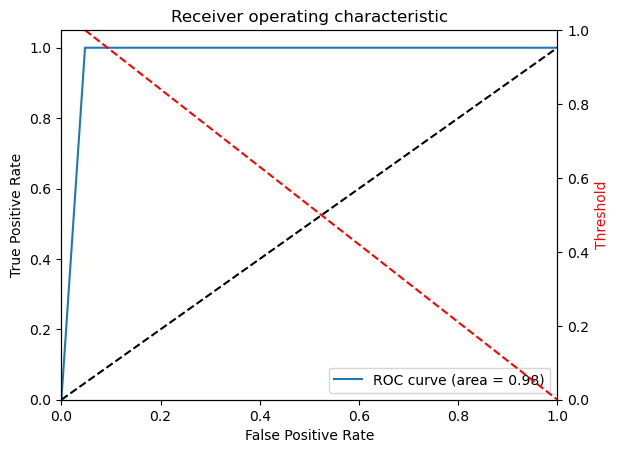

<Figure size 640x480 with 0 Axes>

In [21]:
# numpyライブラリを np としてインポート
import numpy as np

# ROC曲線を生成するためにroc_curve関数を使用
# test_labelsは実際のクラスラベル、target_predictedは予測されたクラスラベル
# roc_curve関数は、実際のクラスラベル（test_labels）と、それに対応する予測されたクラスラベル（target_predicted）を入力として受け取り、
# 偽陽性率（FPR）、真陽性率（TPR）、および閾値（thresholds）を返します。
fpr, tpr, thresholds = roc_curve(test_labels, target_predicted_binary)

# AUC（Area Under the Curve）を計算するためにauc関数を使用
# auc関数を使用してROC曲線の下の面積（AUC）を計算しています。
# これにより、モデルの予測性能を評価する指標としてROC-AUCが取得されます。
roc_auc = auc(fpr, tpr)

# 新しい図（プロット領域）を作成
plt.figure()

# ROC曲線をプロットし、曲線下面積（AUC）をラベルに表示
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % (roc_auc))

# 対角線（ランダムな予測の場合の期待値）を点線でプロット
plt.plot([0, 1], [0, 1], 'k--')

# x軸の表示範囲を設定
plt.xlim([0.0, 1.0])

# y軸の表示範囲を設定
plt.ylim([0.0, 1.05])

# x軸のラベルを設定
plt.xlabel('False Positive Rate')

# y軸のラベルを設定
plt.ylabel('True Positive Rate')

# プロットのタイトルを設定
plt.title('Receiver operating characteristic')

# 凡例を右下に表示
plt.legend(loc="lower right")
 
# 右側のy軸を共有した2番目のプロットエリアを作成
ax2 = plt.gca().twinx()

# 偽陽性率（fpr）と閾値（thresholds）の関係を赤い破線でプロット
ax2.plot(fpr, thresholds, markeredgecolor='r',linestyle='dashed', color='r')

# 右側のy軸におけるラベルを設定
ax2.set_ylabel('Threshold',color='r')

# 閾値の範囲を逆順に設定
#ax2.set_ylim([thresholds[-1],thresholds[0]])

# thresholds リストをクリーンアップする
thresholds = [value for value in thresholds if np.isfinite(value)]

# クリーンアップした thresholds を使用してプロットを行う
ax2.set_ylim([min(thresholds), max(thresholds)])

# fprの範囲を設定
ax2.set_xlim([fpr[0],fpr[-1]])

# 空の新しい図（Figure）を作成
print(plt.figure())

# お疲れ様でした。

このラボを完了しました。ラボガイドの手順に従ってラボを終了してください。